In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rc("font", family = "Malgun Gothic")
# sns.set(font="Malgun Gothic", 
# rc={"axes.unicode_minus":False}, style='white')

# 한글 폰트 설정 (Mac)
plt.rc('font', family='AppleGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

<class 'pandas.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   지점                  1077 non-null   int64  
 1   지점명                 1077 non-null   str    
 2   일시                  1077 non-null   str    
 3   평균기온(°C)            1077 non-null   float64
 4   평균현지기압(hPa)         1077 non-null   float64
 5   평균해면기압(hPa)         1077 non-null   float64
 6   평균수증기압(hPa)         1077 non-null   float64
 7   평균상대습도(%)           1077 non-null   float64
 8   월합강수량(00~24h만)(mm)  1077 non-null   float64
 9   평균풍속(m/s)           1077 non-null   float64
 10  일조율(%)              1077 non-null   float64
 11  최심적설(cm)            1077 non-null   float64
 12  평균지면온도(°C)          1077 non-null   float64
 13  years               1077 non-null   int64  
 14  month               1077 non-null   int64  
 15  시도                  1077 non-null   str    
 16  시군구              

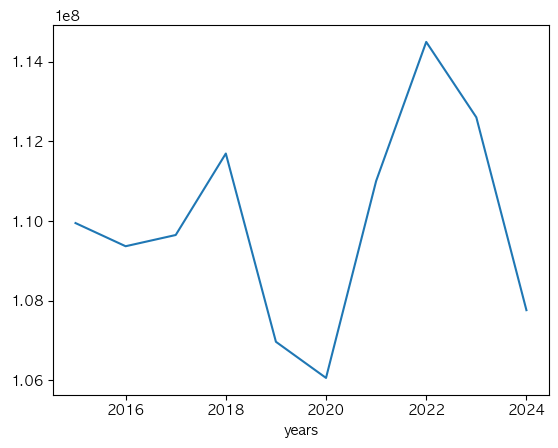

In [10]:
gangwon_total = pd.read_csv('./data/merge_file_gangwon/합 계_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_total = gangwon_total[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]
gangwon_total.info()
gr_year = gangwon_total.groupby(['years'])['전력량'].mean()
gr_year.plot(x='years', y='전력량')
plt.show()

<Axes: xlabel='평균기온(°C)', ylabel='전력량'>

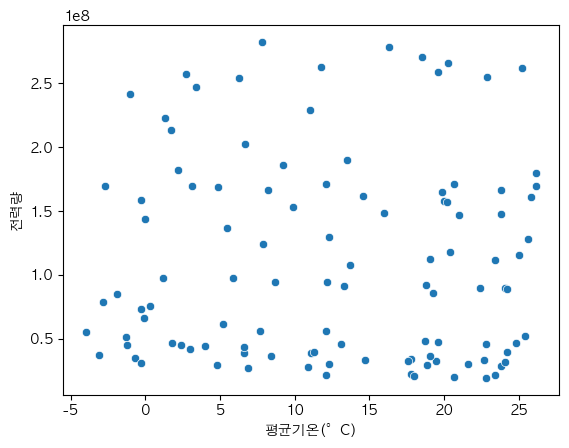

In [11]:
# 2015년 강원도의 전력량 대비 온도 비교 그래프
gangwon_2015 = gangwon_total[gangwon_total['years']==2015]
sns.scatterplot(data=gangwon_2015,x='평균기온(°C)',y='전력량')


array([<Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>,
       <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>,
       <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>, <Axes: xlabel='전력량'>,
       <Axes: xlabel='전력량'>], dtype=object)

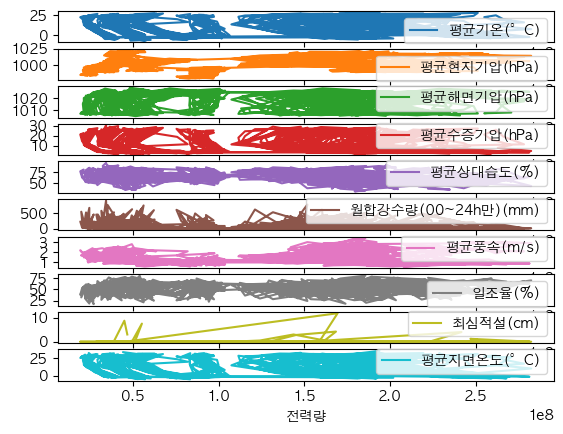

In [12]:
# 전체 강원도의 전력 별 날씨 컬럼 데이터 (비선형)
import matplotlib.pyplot as plt
gangwon_total.plot(y=['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)','평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)','최심적설(cm)', '평균지면온도(°C)'],x='전력량',
                   label=['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)','평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)','최심적설(cm)', '평균지면온도(°C)'],subplots=True)

In [13]:
gangwon_total.columns

Index(['지점', '지점명', '일시', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
       '평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',
       '최심적설(cm)', '평균지면온도(°C)', 'years', 'month', '시도', '시군구', '계약종별', '전력량'],
      dtype='str')

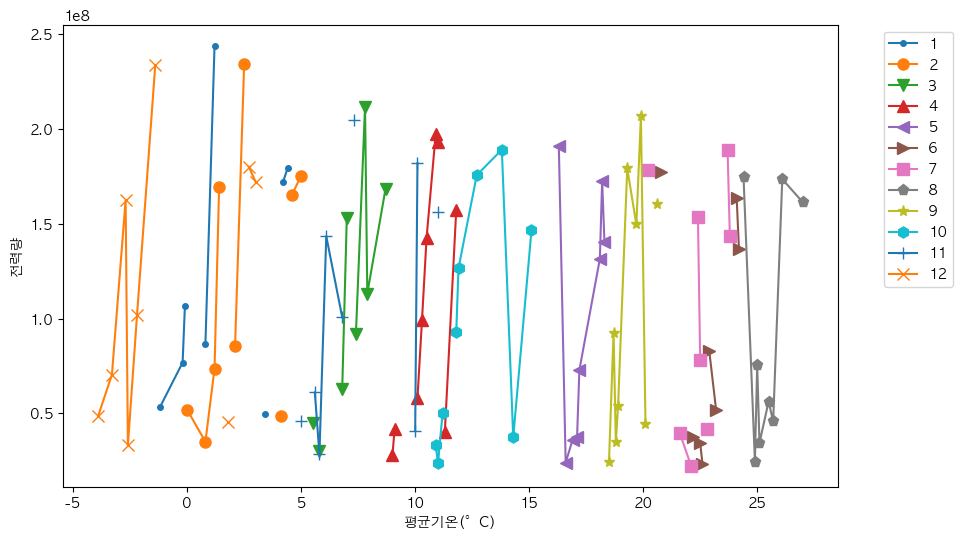

In [14]:
# 2020년 강원도 월별 평균기온의 전력량
gang_2020 = gangwon_total[gangwon_total['years']==2020]
gang_2020 = gang_2020.groupby(['month','평균기온(°C)'])['전력량'].mean().reset_index()

df_pivoted = gang_2020.pivot(index='평균기온(°C)', columns='month', values='전력량')

markers = ['.', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', '+', 'x']

ax = df_pivoted.plot(kind='line', figsize=(10, 6))
for i, line in enumerate(ax.get_lines()):
    if i < len(markers):
        line.set_marker(markers[i])
        line.set_markersize(8)  # 마커 크기 조절 (선택사항)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례 위치 조정
plt.ylabel('전력량')
plt.show()

     month  years           전력량
0        1   2015  1.283634e+08
1        1   2016  1.240950e+08
2        1   2017  1.237394e+08
3        1   2018  1.297475e+08
4        1   2019  1.272076e+08
..     ...    ...           ...
115     12   2020  1.165143e+08
116     12   2021  1.231675e+08
117     12   2022  1.154426e+08
118     12   2023  1.169788e+08
119     12   2024  1.138095e+08

[120 rows x 3 columns]


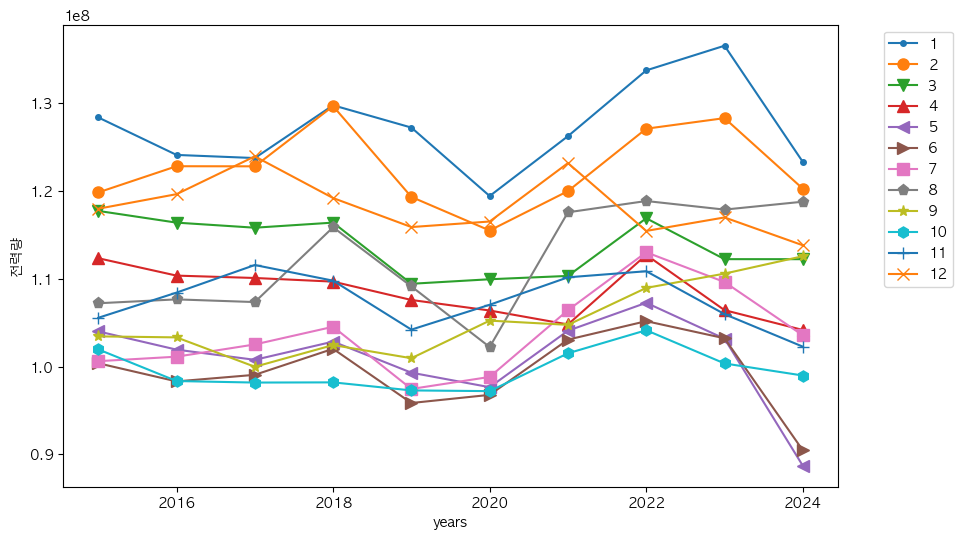

In [15]:
# 2020년 각 연도별 월 평균 전력량 비교
gang_2020 = gangwon_total[gangwon_total['years']==2020]
test = gangwon_total.groupby(['month','years'])['전력량'].mean().reset_index()
print(test)

df_pivoted = test.pivot(index='years', columns='month', values='전력량')

markers = ['.', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', '+', 'x']

ax = df_pivoted.plot(kind='line', figsize=(10, 6))
for i, line in enumerate(ax.get_lines()):
    if i < len(markers):
        line.set_marker(markers[i])
        line.set_markersize(8)  # 마커 크기 조절 (선택사항)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례 위치 조정
plt.ylabel('전력량')
plt.show()

### 교육용 농업용,산업용, 가로등, 심야, 일반용, 주택용

In [16]:
gangwon_general = pd.read_csv('./data/merge_file_gangwon/일반용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_house = pd.read_csv('./data/merge_file_gangwon/주택용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_light = pd.read_csv('./data/merge_file_gangwon/가로등_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_farm = pd.read_csv('./data/merge_file_gangwon/농사용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_edu = pd.read_csv('./data/merge_file_gangwon/교육용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_night = pd.read_csv('./data/merge_file_gangwon/심 야_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_industry = pd.read_csv('./data/merge_file_gangwon/산업용_elect_temp_gangwon.csv',encoding='utf-8')

gangwon_general = gangwon_general[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]


gangwon_house = gangwon_house[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]

gangwon_light = gangwon_light[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]

gangwon_farm = gangwon_farm[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]

gangwon_edu = gangwon_edu[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]

gangwon_night = gangwon_night[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]


gangwon_industry = gangwon_industry[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]


In [17]:
# gangwon_night['계약종별'][0]
# gangwon_general
# gangwon_house 
# gangwon_light 
# gangwon_farm 
# gangwon_edu 
# gangwon_night


Index(['지점', '지점명', '일시', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
       '평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',
       '최심적설(cm)', '평균지면온도(°C)', 'years', 'month', '시도', '시군구', '계약종별', '전력량'],
      dtype='str')


dict_keys(['주택용', '일반용', '교육용', '산업용', '농사용', '심야', '가로등', '합 계'])

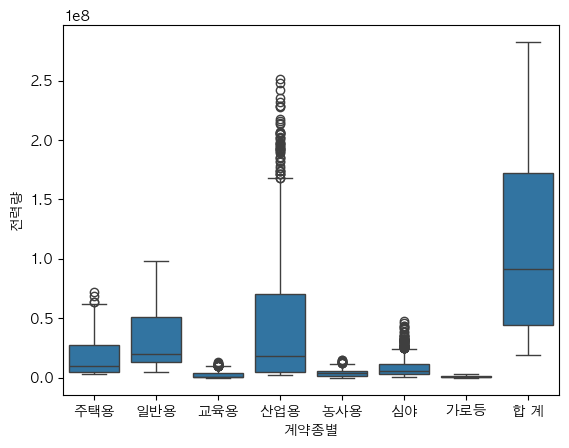

In [34]:
dfs = {
    '주택용': gangwon_house,
    '일반용': gangwon_general,
    '교육용': gangwon_edu,
    '산업용': gangwon_industry,
    '농사용': gangwon_farm,
    '심야': gangwon_night,
    '가로등': gangwon_light,
    '합 계' : gangwon_total
}

all_frame = []
for name, df in dfs.items():
    temp = df.copy()
    temp['계약종별'] = name
    all_frame.append(temp)

gangwon_type = pd.concat(all_frame,ignore_index=True)
gangwon_type.groupby(['years'])['전력량'].mean()
sns.boxplot(data=gangwon_type, x='계약종별', y='전력량')

print(gangwon_type.keys())
dfs.keys()

In [33]:
gr_year = gangwon_type.groupby(['계약종별','years'])['전력량'].mean()
gr_year
# gr_year.plot(x='계약종별', y='전력량')
# gr_year.pivot(index='계약종별', columns='years', values='전력량')
# plt.show()


계약종별  years
가로등   2015     1.105429e+06
      2016     1.184375e+06
      2017     1.238866e+06
      2018     1.257505e+06
      2019     1.216748e+06
                   ...     
주택용   2020     1.679333e+07
      2021     1.755997e+07
      2022     1.787537e+07
      2023     1.818808e+07
      2024     1.882207e+07
Name: 전력량, Length: 70, dtype: float64